In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Callable
import numpy as np
from scipy.interpolate import RegularGridInterpolator


# ============================================================
# 1. REGIMES
# ============================================================

REGIMES_X_HF = ("X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = REGIMES_X_HF

    def __post_init__(self) -> None:
        allowed = {"X", "HF"}
        invalid = [m for m in self.active_modes if m not in allowed]
        if invalid:
            raise ValueError(f"Invalid regimes: {invalid}")
        if len(self.active_modes) == 0:
            raise ValueError("Need at least one active regime.")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}


# ============================================================
# 2. PARAMETERS FOR THE PDF'S FIXED-s REDUCED-FORM SETUP
# ============================================================

@dataclass
class ModelParams:
    # Dynamic
    beta: float = 0.95

    # Depreciation
    delta_H: float = 0.10
    delta_F: float = 0.10

    # Convex adjustment costs:
    # C_H(i_H)= i_H + phi_H/2 * i_H^2
    # C_F(i_F)= i_F + phi_F/2 * i_F^2
    phi_H: float = 0.40
    phi_F: float = 0.40

    # Terminal scrap values
    xi_H: float = 0.40
    xi_F: float = 0.40

    # Reduced-form profit parameters from the PDF
    Omega_H: float = 1.00
    Omega_X: float = 0.35
    Omega_F: float = 1.10
    kappa: float = 0.30
    rho: float = 1.00

    # Fixed operating costs
    f_H_op: float = 0.03
    f_X_op: float = 0.015
    f_F_op: float = 0.03

    # Sunk costs
    f_F_E: float = 0.10
    f_scope: float = 0.05
    f_X_E: float = 0.00  # optional, only for defining s_X^in if wanted

    # Numerical
    eps: float = 1e-10


# ============================================================
# 3. PROFITS, COSTS, LAWS OF MOTION
# ============================================================

def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def investment_cost(i: float, phi: float) -> float:
    return i + 0.5 * phi * i**2


def next_KH(KH: float, iH: float, p: ModelParams) -> float:
    return (1.0 - p.delta_H) * KH + iH


def next_KF(KF: float, iF: float, p: ModelParams) -> float:
    return (1.0 - p.delta_F) * KF + iF


def terminal_value(KH: float, KF: float, p: ModelParams) -> float:
    return p.xi_H * KH + p.xi_F * KF


def switching_cost(prev_mode: str, new_mode: str, p: ModelParams) -> float:
    if prev_mode == new_mode:
        return 0.0
    if prev_mode == "X" and new_mode == "HF":
        return p.f_F_E + p.f_scope
    if prev_mode == "HF" and new_mode == "X":
        return 0.0  # matches the optional downgrading case in the PDF
    raise ValueError(f"Unsupported transition: {prev_mode} -> {new_mode}")


def profit_D(KH: float, s: float, p: ModelParams) -> float:
    return p.Omega_H * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op


def profit_X(KH: float, s: float, p: ModelParams) -> float:
    Omega_eX = p.Omega_H + p.Omega_X
    return Omega_eX * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op - p.f_X_op


def profit_HF(KH: float, KF: float, s: float, p: ModelParams) -> float:
    home = p.Omega_H * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho)
    foreign = p.Omega_F * _safe_power(KF, p.kappa, p.eps) * (s ** p.rho)
    return home + foreign - p.f_H_op - p.f_F_op


def flow_profit(mode: str, KH: float, KF: float, s: float, p: ModelParams) -> float:
    if mode == "X":
        return profit_X(KH, s, p)
    if mode == "HF":
        return profit_HF(KH, KF, s, p)
    raise ValueError(f"Unknown mode: {mode}")


# ============================================================
# 4. STATIC CUTOFFS FROM THE PDF
# ============================================================

def s_x_out_cutoff(KH: float, p: ModelParams) -> float:
    denom = p.Omega_X * _safe_power(KH, p.kappa, p.eps)
    return (p.f_X_op / max(denom, p.eps)) ** (1.0 / p.rho)


def s_x_in_cutoff(KH: float, p: ModelParams) -> float:
    denom = p.Omega_X * _safe_power(KH, p.kappa, p.eps)
    numer = p.f_X_op + (1.0 - p.beta) * p.f_X_E
    return (numer / max(denom, p.eps)) ** (1.0 / p.rho)


def s_hf_out_cutoff(KH: float, KF: float, p: ModelParams) -> Optional[float]:
    denom = p.Omega_F * _safe_power(KF, p.kappa, p.eps) - p.Omega_X * _safe_power(KH, p.kappa, p.eps)
    if denom <= 0.0:
        return None
    numer = p.f_F_op - p.f_X_op
    return (numer / denom) ** (1.0 / p.rho)


def s_hf_in_cutoff(KH: float, KF: float, p: ModelParams) -> Optional[float]:
    denom = p.Omega_F * _safe_power(KF, p.kappa, p.eps) - p.Omega_X * _safe_power(KH, p.kappa, p.eps)
    if denom <= 0.0:
        return None
    numer = p.f_F_op - p.f_X_op + (1.0 - p.beta) * (p.f_F_E + p.f_scope)
    return (numer / denom) ** (1.0 / p.rho)


def make_s_grid_above_x_cutoff(
    KH0: float,
    p: ModelParams,
    n_s: int = 25,
    s_max: Optional[float] = None,
    pct_buffer: float = 0.05,
) -> np.ndarray:
    """
    Initial productivity support restricted to s >= s_X^out(KH0),
    as in the PDF benchmark.
    """
    s_min = (1.0 + pct_buffer) * s_x_out_cutoff(KH0, p)
    if s_max is None:
        s_max = 3.0 * s_min
    if s_max <= s_min:
        raise ValueError("Need s_max > lower bound.")
    return np.linspace(s_min, s_max, n_s)


# ============================================================
# 5. INTERPOLATION HELPERS
# ============================================================

def _clip(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def nearest_index(grid: np.ndarray, x: float) -> int:
    return int(np.argmin(np.abs(grid - x)))


def local_index_window(center: int, n: int, radius: int) -> np.ndarray:
    lo = max(center - radius, 0)
    hi = min(center + radius, n - 1)
    return np.arange(lo, hi + 1)


def build_value_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    for pm, prev_mode in enumerate(cfg.active_modes):
        for s_idx in range(len(s_grid)):
            interps[(prev_mode, s_idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                V[pm, :, :, s_idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])
    return value_obj


# ============================================================
# 6. LAST DECISION PERIOD
# ============================================================

def terminal_investment_kkt(p: ModelParams) -> Tuple[float, float]:
    """
    In the last decision period:
        1 + phi_H * i_H >= beta * xi_H
        1 + phi_F * i_F >= beta * xi_F
    """
    iH = max((p.beta * p.xi_H - 1.0) / p.phi_H, 0.0)
    iF = max((p.beta * p.xi_F - 1.0) / p.phi_F, 0.0)
    return float(iH), float(iF)


def solve_terminal_branch(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
) -> Dict[str, float]:
    iH, iF = terminal_investment_kkt(p)

    KH_next = next_KH(KH, iH, p)
    KF_next = next_KF(KF, iF, p)

    pi = flow_profit(mode, KH, KF, s, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(iH, p.phi_H) + investment_cost(iF, p.phi_F)
    cont = p.beta * terminal_value(KH_next, KF_next, p)

    return {
        "mode": mode,
        "value": pi - switch - adjust + cont,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "KH_next": KH_next,
        "KF_next": KF_next,
        "continuation": cont,
    }


def solve_terminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, s in enumerate(s_grid):
                    branches = {
                        mode: solve_terminal_branch(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=float(KH),
                            KF=float(KF),
                            s=float(s),
                            p=p,
                        )
                        for mode in cfg.active_modes
                    }

                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]
                    KH_next_star[pm, i, j, k] = best["KH_next"]
                    KF_next_star[pm, i, j, k] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
    }


# ============================================================
# 7. EARLIER PERIODS: FIXED-s LOCAL SEARCH
# ============================================================

def solve_branch_local_search(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s_idx: int,
    s_grid: np.ndarray,
    Vnext_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, float]:
    """
    Conditional on fixed s:
        continuation = beta * V_{t+1}(KH', KF'; s, mode)
    """
    s = float(s_grid[s_idx])

    center_H = nearest_index(KH_grid, (1.0 - p.delta_H) * KH)
    center_F = nearest_index(KF_grid, (1.0 - p.delta_F) * KF)

    n_H = len(KH_grid)
    n_F = len(KF_grid)

    visited = set()
    best: Optional[Dict[str, float]] = None

    for _ in range(max_expansions):
        key = (center_H, center_F)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius)
        idx_F = local_index_window(center_F, n_F, radius)

        best_val = -np.inf
        best_idx: Optional[Tuple[int, int]] = None
        best_local: Optional[Dict[str, float]] = None

        pi = flow_profit(mode, KH, KF, s, p)
        switch = switching_cost(prev_mode, mode, p)

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta_H) * KH
            if iH < -1e-12:
                continue

            for iF_idx in idx_F:
                KF_next = float(KF_grid[iF_idx])
                iF = KF_next - (1.0 - p.delta_F) * KF
                if iF < -1e-12:
                    continue

                adjust = investment_cost(iH, p.phi_H) + investment_cost(iF, p.phi_F)
                cont = p.beta * Vnext_obj(mode, KH_next, KF_next, s_idx)
                val = pi - switch - adjust + cont

                if val > best_val:
                    best_val = val
                    best_idx = (iH_idx, iF_idx)
                    best_local = {
                        "mode": mode,
                        "value": val,
                        "profit": pi,
                        "switch_cost": switch,
                        "iH": float(iH),
                        "iF": float(iF),
                        "KH_next": KH_next,
                        "KF_next": KF_next,
                        "continuation": cont,
                    }

        if best_idx is None or best_local is None:
            raise RuntimeError("No feasible candidate found.")

        best = best_local
        iH_idx, iF_idx = best_idx

        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))
        hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))

        if hit_edge_H or hit_edge_F:
            center_H, center_F = iH_idx, iF_idx
            continue

        break

    if best is None:
        raise RuntimeError("Local search terminated without solution.")

    return best

# Faster version of the above, with direct array lookup instead of interpolation for continuation values
def solve_branch_local_search_direct(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s_idx: int,
    s_grid: np.ndarray,
    V_next: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, float]:
    """
    Same local search as before, but continuation uses direct array lookup
    instead of interpolation.
    """
    s = float(s_grid[s_idx])
    pm_next = cfg.mode_to_index[mode]

    center_H = nearest_index(KH_grid, (1.0 - p.delta_H) * KH)
    center_F = nearest_index(KF_grid, (1.0 - p.delta_F) * KF)

    n_H = len(KH_grid)
    n_F = len(KF_grid)

    visited = set()
    best = None

    pi = flow_profit(mode, KH, KF, s, p)
    switch = switching_cost(prev_mode, mode, p)

    for _ in range(max_expansions):
        key = (center_H, center_F)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius)
        idx_F = local_index_window(center_F, n_F, radius)

        best_val = -np.inf
        best_idx = None
        best_local = None

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta_H) * KH
            if iH < -1e-12:
                continue

            for iF_idx in idx_F:
                KF_next = float(KF_grid[iF_idx])
                iF = KF_next - (1.0 - p.delta_F) * KF
                if iF < -1e-12:
                    continue

                adjust = investment_cost(iH, p.phi_H) + investment_cost(iF, p.phi_F)
                cont = p.beta * V_next[pm_next, iH_idx, iF_idx, s_idx]
                val = pi - switch - adjust + cont

                if val > best_val:
                    best_val = val
                    best_idx = (iH_idx, iF_idx)
                    best_local = {
                        "mode": mode,
                        "value": val,
                        "profit": pi,
                        "switch_cost": switch,
                        "iH": float(iH),
                        "iF": float(iF),
                        "KH_next": KH_next,
                        "KF_next": KF_next,
                        "continuation": cont,
                    }

        if best_idx is None or best_local is None:
            raise RuntimeError("No feasible candidate found.")

        best = best_local
        iH_idx, iF_idx = best_idx

        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))
        hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))

        if hit_edge_H or hit_edge_F:
            center_H, center_F = iH_idx, iF_idx
            continue

        break

    if best is None:
        raise RuntimeError("Local search terminated without solution.")

    return best

def solve_nonterminal_period_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    next_period_sol: Dict[str, object],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    Vnext_obj = next_period_sol["value_callable"]

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for s_idx in range(n_s):
                    branches = {
                        mode: solve_branch_local_search(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=float(KH),
                            KF=float(KF),
                            s_idx=s_idx,
                            s_grid=s_grid,
                            Vnext_obj=Vnext_obj,
                            p=p,
                            KH_grid=KH_grid,
                            KF_grid=KF_grid,
                            radius=radius,
                            max_expansions=max_expansions,
                        )
                        for mode in cfg.active_modes
                    }

                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, s_idx] = best["value"]
                    policy_mode[pm, i, j, s_idx] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, s_idx] = best["iH"]
                    iF_star[pm, i, j, s_idx] = best["iF"]
                    KH_next_star[pm, i, j, s_idx] = best["KH_next"]
                    KF_next_star[pm, i, j, s_idx] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
    }

# Faster version of the above
def solve_nonterminal_period_grid_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    next_period_sol: Dict[str, object],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    V_next = next_period_sol["V"]

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for s_idx in range(n_s):
                    branches = {
                        mode: solve_branch_local_search_direct(
                            mode=mode,
                            prev_mode=prev_mode,
                            KH=float(KH),
                            KF=float(KF),
                            s_idx=s_idx,
                            s_grid=s_grid,
                            V_next=V_next,
                            p=p,
                            cfg=cfg,
                            KH_grid=KH_grid,
                            KF_grid=KF_grid,
                            radius=radius,
                            max_expansions=max_expansions,
                        )
                        for mode in cfg.active_modes
                    }

                    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
                    best = branches[best_mode]

                    V[pm, i, j, s_idx] = best["value"]
                    policy_mode[pm, i, j, s_idx] = cfg.mode_to_index[best_mode]
                    iH_star[pm, i, j, s_idx] = best["iH"]
                    iF_star[pm, i, j, s_idx] = best["iF"]
                    KH_next_star[pm, i, j, s_idx] = best["KH_next"]
                    KF_next_star[pm, i, j, s_idx] = best["KF_next"]

    interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V, cfg)
    value_obj = make_value_callable(KH_grid, KF_grid, interps)

    return {
        "V": V,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": interps,
        "value_callable": value_obj,
    }

# ============================================================
# 8. GENERIC FIXED-s FINITE-HORIZON SOLVER
# ============================================================

def solve_fixed_s_finite_horizon(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    n_periods: int,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    """
    Decision periods t = 0, ..., n_periods-1
    Terminal liquidation at t = n_periods

    This is the natural extension of the PDF's 3-period benchmark to any finite horizon.
    """
    if n_periods < 1:
        raise ValueError("Need n_periods >= 1.")

    period_solutions: List[Optional[Dict[str, object]]] = [None] * n_periods

    # Last decision period
    period_solutions[-1] = solve_terminal_period_grid(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    # Backward induction
    for t in range(n_periods - 2, -1, -1):
        period_solutions[t] = solve_nonterminal_period_grid_fast(
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            s_grid=s_grid,
            next_period_sol=period_solutions[t + 1],
            p=p,
            cfg=cfg,
            radius=radius,
            max_expansions=max_expansions,
        )

    return {
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "s_grid": s_grid,
        "n_periods": n_periods,
        "p": p,
        "cfg": cfg,
        "period_solutions": period_solutions,
        "solution_t0": period_solutions[0],
        "solver_type": "fixed_s_pdf",
    }


# ============================================================
# 9. OPTIONAL: SAMPLE INITIAL s FROM THE TRUNCATED SUPPORT
# ============================================================

def draw_initial_s_indices(
    s_grid: np.ndarray,
    n_firms: int,
    probs: Optional[np.ndarray] = None,
    seed: int = 123,
) -> np.ndarray:
    """
    Draw indices from the already-truncated s_grid.
    If probs is None: uniform on the truncated support.
    """
    rng = np.random.default_rng(seed)
    if probs is None:
        probs = np.ones(len(s_grid)) / len(s_grid)
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    return rng.choice(np.arange(len(s_grid)), size=n_firms, p=probs)


# ============================================================
# 10. OPTIONAL: DETERMINISTIC POLICY SIMULATION GIVEN s
# ============================================================

def simulate_one_path(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    initial_prev_mode: str = "X",
) -> Dict[str, object]:
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    cfg = model_bundle["cfg"]
    n_periods = model_bundle["n_periods"]
    period_solutions = model_bundle["period_solutions"]

    KH_path = [float(KH0)]
    KF_path = [float(KF0)]
    s_idx_path = [int(s0_idx)]
    s_path = [float(s_grid[s0_idx])]
    mode_path: List[str] = []
    iH_path: List[float] = []
    iF_path: List[float] = []

    prev_mode = initial_prev_mode

    for t in range(n_periods):
        sol_t = period_solutions[t]

        i = nearest_index(KH_grid, KH_path[-1])
        j = nearest_index(KF_grid, KF_path[-1])
        k = s_idx_path[-1]
        pm = cfg.mode_to_index[prev_mode]

        mode = cfg.index_to_mode[int(sol_t["policy_mode"][pm, i, j, k])]
        iH = float(sol_t["iH_star"][pm, i, j, k])
        iF = float(sol_t["iF_star"][pm, i, j, k])
        KH_next = float(sol_t["KH_next_star"][pm, i, j, k])
        KF_next = float(sol_t["KF_next_star"][pm, i, j, k])

        mode_path.append(mode)
        iH_path.append(iH)
        iF_path.append(iF)
        KH_path.append(KH_next)
        KF_path.append(KF_next)

        if t < n_periods - 1:
            s_idx_path.append(k)
            s_path.append(float(s_grid[k]))

        prev_mode = mode

    return {
        "KH_path": KH_path,
        "KF_path": KF_path,
        "s_idx_path": s_idx_path,
        "s_path": s_path,
        "mode_path": mode_path,
        "iH_path": iH_path,
        "iF_path": iF_path,
    }


def print_path_summary(path: Dict[str, object], label: str = "path") -> None:
    print(f"\n=== {label} ===")
    print("modes:   ", path["mode_path"])
    print("iH path: ", [round(x, 4) for x in path["iH_path"]])
    print("iF path: ", [round(x, 4) for x in path["iF_path"]])
    print("KH path: ", [round(x, 4) for x in path["KH_path"]])
    print("KF path: ", [round(x, 4) for x in path["KF_path"]])
    print("s path:  ", [round(x, 4) for x in path["s_path"]])

# Analysis 

In [9]:
cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH0 = 0.50
KF0 = 0.00

KH_grid = np.linspace(0.10, 4.0, 40)
KF_grid = np.linspace(0.00, 2.5, 25)
s_grid  = make_s_grid_above_x_cutoff(KH0=KH0, p=p, n_s=15, s_max=2.2)

sol = solve_fixed_s_finite_horizon(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    n_periods=9,
    p=p,
    cfg=cfg,
    radius=4,
    max_expansions=3,
)

#### Helpers

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def first_entry_period(path, target_mode="HF"):
    """
    Returns the first period t in which the chosen mode is target_mode.
    Returns np.nan if the firm never enters target_mode.
    """
    for t, m in enumerate(path["mode_path"]):
        if m == target_mode:
            return t
    return np.nan


def ever_enters_mode(path, target_mode="HF"):
    return int(any(m == target_mode for m in path["mode_path"]))


def feasible_s_mask_for_KH0(KH0, s_grid, p):
    """
    Feasible exporter states at t=0 with KF0=0:
        s >= s_X^out(KH0)
    """
    cutoff = s_x_out_cutoff(KH0, p)
    return s_grid >= cutoff


def feasible_s_indices_for_KH0(KH0, s_grid, p):
    mask = feasible_s_mask_for_KH0(KH0, s_grid, p)
    return np.where(mask)[0]


def nearest_s_index(s_grid, s0):
    return int(np.argmin(np.abs(s_grid - s0)))

### Feasible set

In [13]:
def build_feasible_initial_state_df(KH0_vals, s_grid, p, KF0=0.0):
    """
    Returns a DataFrame with all (KH0, s0) points and whether they are feasible
    exporter initial conditions under KF0=0.
    """
    rows = []
    for KH0 in KH0_vals:
        cutoff = s_x_out_cutoff(KH0, p)
        for s0 in s_grid:
            feasible = int(s0 >= cutoff)
            rows.append({
                "KH0": float(KH0),
                "KF0": float(KF0),
                "s0": float(s0),
                "s_x_out": float(cutoff),
                "feasible_exporter": feasible,
            })
    return pd.DataFrame(rows)

def plot_feasible_state_set(feasible_df):
    df = feasible_df.copy()
    pivot = (
        df.pivot(index="s0", columns="KH0", values="feasible_exporter")
          .sort_index()
    )

    Z = np.ma.masked_where(pivot.values == 0, pivot.values)

    cmap = plt.cm.Greens.copy()
    cmap.set_bad(color="white")

    plt.figure(figsize=(7, 5))
    plt.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[pivot.columns.min(), pivot.columns.max(),
                pivot.index.min(), pivot.index.max()],
        cmap=cmap,
    )
    plt.colorbar(label="Feasible exporter state")
    plt.xlabel(r"$K_{H,0}$")
    plt.ylabel(r"$s$")
    plt.title(r"Feasible initial exporter states: $s \geq s_X^{out}(K_{H,0})$")
    plt.show()

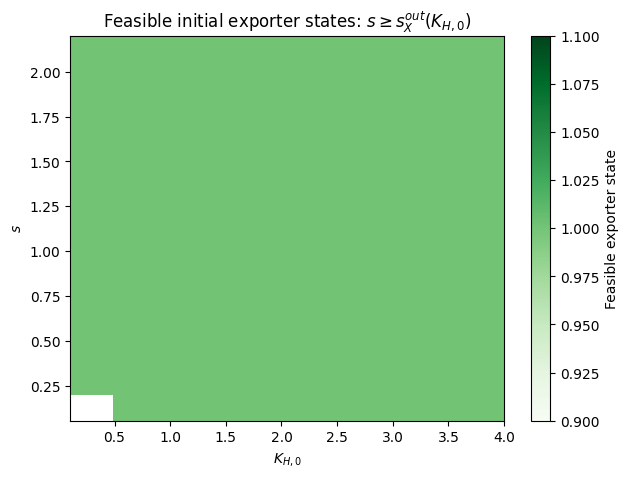

In [14]:
KH0_vals = KH_grid.copy()      # or np.linspace(0.1, 4.0, 40)
s_vals = sol["s_grid"]         # use the same s-grid as in the solved model

feasible_df = build_feasible_initial_state_df(KH0_vals, s_vals, p, KF0=0.0)
plot_feasible_state_set(feasible_df)

### Simulate

In [15]:
def evaluate_all_feasible_initial_states(
    model_bundle,
    KH0_vals,
    KF0=0.0,
    initial_prev_mode="X",
):
    """
    For every feasible (KH0, s0) on the model's state grid, simulate the path once.
    Because the model is deterministic conditional on s, this fully characterizes the
    state map over (KH0, s0).
    """
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]

    rows = []

    for KH0 in KH0_vals:
        feasible_idx = feasible_s_indices_for_KH0(KH0, s_grid, p)

        for s_idx in feasible_idx:
            s0 = float(s_grid[s_idx])

            path = simulate_one_path(
                model_bundle=model_bundle,
                KH0=float(KH0),
                KF0=float(KF0),
                s0_idx=int(s_idx),
                initial_prev_mode=initial_prev_mode,
            )

            entry_t = first_entry_period(path, target_mode="HF")

            rows.append({
                "KH0": float(KH0),
                "KF0": float(KF0),
                "s0": s0,
                "ever_HF": ever_enters_mode(path, target_mode="HF"),
                "entry_period": entry_t,
                "final_mode": path["mode_path"][-1],
                "path": path,
            })

    return pd.DataFrame(rows)

# Monte carlo. For each K_h,0 drawing firms wiht s from feasible support and simulating their paths
def simulate_many_firms_by_KH0(
    model_bundle,
    KH0_vals,
    N=300,
    KF0=0.0,
    initial_prev_mode="X",
    seed=123,
    s_probs=None,
):
    """
    For each KH0, draw N initial s indices from the feasible support and simulate.
    If s_probs is None, draws uniformly over feasible s-grid points.
    If s_probs is provided, it must be an array of length len(s_grid) with weights
    for the full s-grid; it will be renormalized on the feasible subset.
    """
    rng = np.random.default_rng(seed)
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]

    rows = []

    for KH0 in KH0_vals:
        feasible_idx = feasible_s_indices_for_KH0(KH0, s_grid, p)
        if len(feasible_idx) == 0:
            continue

        if s_probs is None:
            probs = np.ones(len(feasible_idx)) / len(feasible_idx)
        else:
            probs = np.asarray(s_probs)[feasible_idx].astype(float)
            probs = probs / probs.sum()

        drawn_idx = rng.choice(feasible_idx, size=N, replace=True, p=probs)

        for n, s_idx in enumerate(drawn_idx):
            path = simulate_one_path(
                model_bundle=model_bundle,
                KH0=float(KH0),
                KF0=float(KF0),
                s0_idx=int(s_idx),
                initial_prev_mode=initial_prev_mode,
            )

            entry_t = first_entry_period(path, target_mode="HF")

            rows.append({
                "KH0": float(KH0),
                "firm_id": int(n),
                "s0_idx": int(s_idx),
                "s0": float(s_grid[s_idx]),
                "ever_HF": ever_enters_mode(path, target_mode="HF"),
                "entry_period": entry_t,
                "path": path,
            })

    return pd.DataFrame(rows)

In [16]:
state_results_df = evaluate_all_feasible_initial_states(
    model_bundle=sol,
    KH0_vals=KH0_vals,
    KF0=0.0,
    initial_prev_mode="X",
)

state_results_df.head()

mc_df = simulate_many_firms_by_KH0(
    model_bundle=sol,
    KH0_vals=KH0_vals,
    N=300,
    KF0=0.0,
    initial_prev_mode="X",
    seed=123,
)

### Heatmaps

In [17]:
def plot_heatmap_from_state_df(df, value_col, title, cmap="viridis", cbar_label=None):
    pivot = (
        df.pivot(index="s0", columns="KH0", values=value_col)
          .sort_index()
    )

    Z = np.ma.masked_invalid(pivot.values)
    cmap_obj = plt.cm.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="white")

    plt.figure(figsize=(7, 5))
    im = plt.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[pivot.columns.min(), pivot.columns.max(),
                pivot.index.min(), pivot.index.max()],
        cmap=cmap_obj,
    )
    plt.xlabel(r"$K_{H,0}$")
    plt.ylabel(r"$s$")
    plt.title(title)
    plt.colorbar(im, label=cbar_label if cbar_label else value_col)
    plt.show()

/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_73300/1753722757.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()


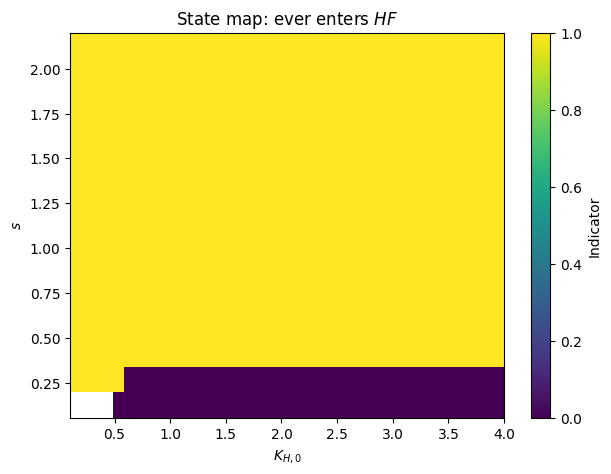

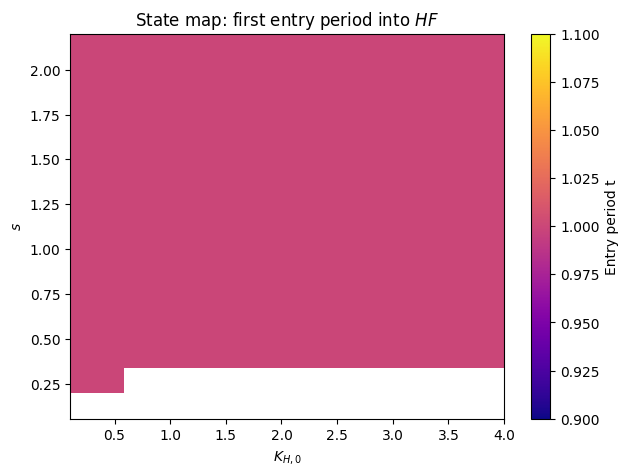

In [18]:
# 0/1 map: does the firm ever switch from X to HF?
plot_heatmap_from_state_df(
    state_results_df,
    value_col="ever_HF",
    title=r"State map: ever enters $HF$",
    cmap="viridis",
    cbar_label="Indicator"
)

# Entry period map
plot_heatmap_from_state_df(
    state_results_df,
    value_col="entry_period",
    title=r"State map: first entry period into $HF$",
    cmap="plasma",
    cbar_label="Entry period t"
)

### Investment paths